<a href="https://colab.research.google.com/github/alonsap/aaa/blob/main/%D7%9E%D7%98%D7%9C%D7%94_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **מטלה 2**
## חקירת דאטה שמיוצר על ידי בינה מלאכותית

**מגיש:** אלון ספיר
**תעודת זהות:** 214316762
**מרצה:** שי גול

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files

In [5]:
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)
print("Matrix of:",df.shape)


df.head()

Saving chess_dataset.csv to chess_dataset (2).csv
Matrix of: (3000, 15)


,player_id,age,years_of_experience,region,family_chess_background,has_chess_coach,hours_studied_per_week,tournaments_played_last_year,preferred_time_control,primary_opening_style,tactics_puzzle_rating,tilt_factor,chess_events_il_premium_tier,estimated_elo,win_vs_club_player_1500
0,1001,NaN,39.0,Asia,0.0,0.0,0.0,4.0,Rapid,Positional,2174.0,0.69,Free,2037.0,1.0
1,1002,24.0,NaN,Americas,1.0,0.0,0.4,1.0,Classical,Positional,1001.0,NaN,Free,985.0,0.0
2,1003,70.0,23.0,NaN,1.0,1.0,11.6,7.0,Rapid,Positional,2002.0,0.37,Free,1798.0,1.0
3,1004,30.0,23.0,East Europe & Russia,0.0,0.0,7.9,3.0,Bullet,Defensive,2211.0,0.21,Pro,2006.0,1.0
4,1005,33.0,9.0,Americas,0.0,0.0,0.0,2.0,Rapid,Aggressive,1289.0,0.25,NaN,1030.0,0.0


<div dir="rtl">

### **1. חקירת משתנים קטגוריאליים (תרשימי עמודות)**
בשלב זה נבחן את הקשר בין מאפיינים קטגוריאליים של השחקנים (כמו סגנון פתיחה מועדף וקצב משחק) לבין משתנה המטרה - הניצחון מול שחקן ברמת 1500 (`win_vs_club_player_1500`).
נשתמש בתרשימי עמודות כדי לראות את התפלגות הניצחונות וההפסדים בכל קטגוריה, מה שיעזור לנו לזהות קשרים ראשוניים.

</div>

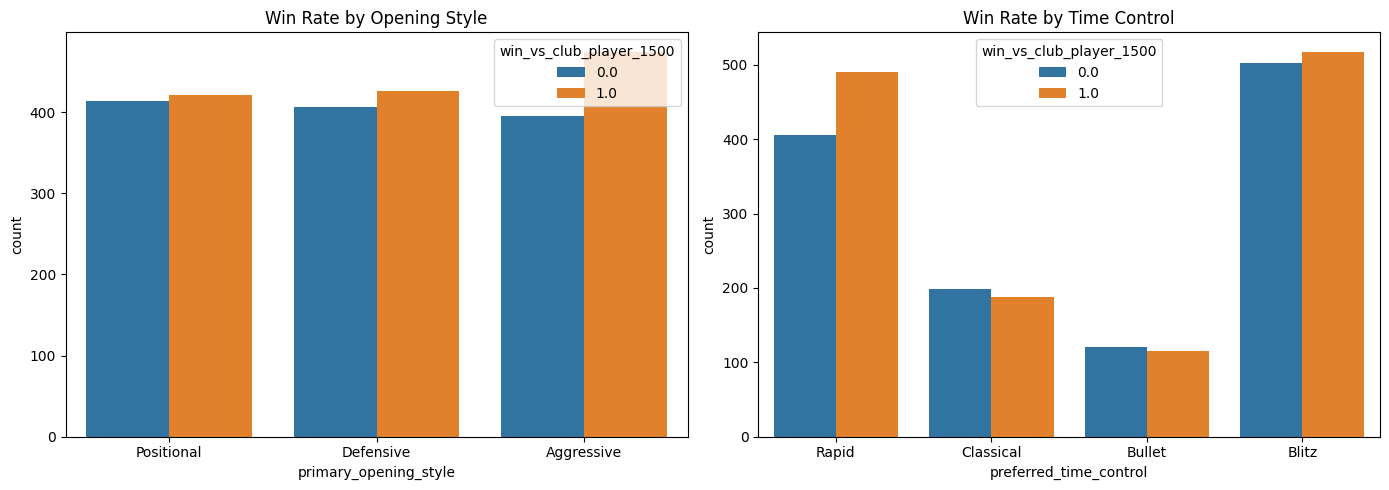

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# תרשים 1: סגנון פתיחה ביחס למשתנה המטרה
sns.countplot(data=df, x='primary_opening_style', hue='win_vs_club_player_1500', ax=axes[0])
axes[0].set_title('Win Rate by Opening Style')

# תרשים 2: קצב משחק מועדף ביחס למשתנה המטרה
sns.countplot(data=df, x='preferred_time_control', hue='win_vs_club_player_1500', ax=axes[1])
axes[1].set_title('Win Rate by Time Control')

plt.tight_layout()
plt.show()

<div dir="rtl">

### **2. מסקנות על המשתנים הקטגוריאליים ביחס למשתנה המטרה (מובהקות)**
מתוך התבוננות בתרשימים, ניתן לזהות קשר ברור בין סגנון המשחק לבין סיכויי הניצחון.

* **סגנון פתיחה:** שחקנים המאופיינים בסגנון פתיחה "אגרסיבי" מציגים יחס ניצחונות גבוה יותר מאשר הפסדים מול שחקני מועדון (1500), לעומת סגנונות הגנתיים או עמדתיים שבהם יחס הניצחונות נמוך או שווה להפסדים.
* **קצב משחק:** בקרב שחקנים המעדיפים שחמט מהיר (Rapid), כמות הניצחונות גבוהה בצורה בולטת מכמות ההפסדים.

**מסקנה:** משתנים אלו מראים מובהקות ויזואלית ומכילים כוח ניבויי משמעותי, ולכן סביר מאוד שהם יתרמו למודל החיזוי ויש לכלול אותם.

</div>

<div dir="rtl">

### **3. חלוקת משתנה רציף לאינטרבלים (Binning)**
משתנה הגיל (`age`) בנתונים שלנו הוא רציף. כדי לעזור למודל לזהות תבניות לא-ליניאריות, נחלק אותו לאינטרבלים (Bins) המבוססים על חלוקה הגיונית מעולם השחמט: נוער (עד 18), צעירים (18-35), בוגרים (35-55) וסניורים (55+).
חלוקה זו מקבצת שחקנים בעלי שלבי התפתחות דומים במשחק, ולא מחייבת אינטרבלים בעלי טווח שווה.

</div>

In [7]:
# הגדרת הגבולות של האינטרבלים
age_bins = [0, 18, 35, 55, 120]

# מתן שמות לקבוצות שייצרנו
age_labels = ['Youth (0-18)', 'Young Adults (18-35)', 'Adults (35-55)', 'Seniors (55+)']

# יצירת העמודה החדשה בחיתוך לפי הגבולות
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)

df[['age', 'age_group']].head()

,age,age_group
0,NaN,NaN
1,24.0,Young Adults (18-35)
2,70.0,Seniors (55+)
3,30.0,Young Adults (18-35)
4,33.0,Young Adults (18-35)


<div dir="rtl">

### **4. הנדסת מאפיינים (Feature Engineering) מתוך ה-describe**
מתוך התבוננות בדו"ח הסטטיסטי (`df.describe()`), עולות מספר תובנות המאפשרות יצירת משתנים חדשים:

1. **זיהוי שחקנים פעילים במיוחד (Outliers):** האחוזון ה-75 של כמות הטורנירים בשנה עומד על 5, בעוד המקסימום הוא 18. נייצר משתנה אינדיקטור (`is_highly_active`) שיסמן שחקנים שחורגים מרוב האוכלוסייה ושיחקו מעל 7 טורנירים.
2. **יצירת משתנה יחס (Ratio):** שחקן בן 20 עם 10 שנות ניסיון שונה מהותית משחקן בן 60 עם אותו ניסיון. נייצר משתנה חדש של יחס הניסיון מתוך שנות החיים (`experience_to_age_ratio`), כדי לנרמל את שנות הניסיון ביחס לגיל.

</div>

In [8]:
# 1. משתנה בינארי לפעילות חריגה
df['is_highly_active'] = (df['tournaments_played_last_year'] > 7).astype(int)

# 2. משתנה יחס המנרמל את הניסיון לפי גיל השחקן
df['experience_to_age_ratio'] = df['years_of_experience'] / df['age']

# מילוי ערכים חסרים ב-0 (למקרה של חלוקה באפס או חוסר נתונים)
df['experience_to_age_ratio'] = df['experience_to_age_ratio'].fillna(0)

df[['age', 'years_of_experience', 'experience_to_age_ratio', 'tournaments_played_last_year', 'is_highly_active']].head()

,age,years_of_experience,experience_to_age_ratio,tournaments_played_last_year,is_highly_active
0,NaN,39.0,0.000000,4.0,0
1,24.0,NaN,0.000000,1.0,0
2,70.0,23.0,0.328571,7.0,0
3,30.0,23.0,0.766667,3.0,0
4,33.0,9.0,0.272727,2.0,0
